In [21]:
#Import the libraries 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
#Loading the dataset 
df1=pd.read_csv("2020-2025_CLEAN.csv")
df2=pd.read_csv("Customer-Churn-Records_CLEAN.csv")

# Part 1: Macro-Economic Data (2020-2025)

In [15]:
#Key metrics and Summary 
print("\nGlobal Summary Statistics (2020-2025)---")
print(df1.describe())


Global Summary Statistics (2020-2025)---
               2020          2021          2022          2023          2024  \
count  1.960000e+02  1.960000e+02  1.960000e+02  1.960000e+02  1.960000e+02   
mean   4.378886e+05  4.995205e+05  5.204605e+05  5.433356e+05  5.644293e+05   
std    1.942936e+06  2.209962e+06  2.336347e+06  2.440987e+06  2.547862e+06   
min    5.200000e+01  6.200000e+01  6.100000e+01  6.300000e+01  6.500000e+01   
25%    9.588000e+03  1.067050e+04  1.255575e+04  1.317975e+04  1.350050e+04   
50%    3.533450e+04  3.771900e+04  4.156800e+04  4.363100e+04  4.546600e+04   
75%    2.074810e+05  2.513878e+05  2.629442e+05  2.755445e+05  2.858750e+05   
max    2.135412e+07  2.368118e+07  2.600690e+07  2.772072e+07  2.918490e+07   

               2025  Total_Growth_%  Absolute_Growth  
count  1.960000e+02      196.000000     1.960000e+02  
mean   5.805673e+05       44.669833     1.426787e+05  
std    2.646492e+06       37.383581     7.372872e+05  
min    6.500000e+01      -

In [12]:
# Growth Calculations
df1["Total_Growth_%"] = (
    (df1["2025"] - df1["2020"]) / df1["2020"]
) * 100
df1["Absolute_Growth"] = df1["2025"] - df1["2020"]

print("\nTop 5 Highest Growth Countries (2020-2025):")
print(
    df1.sort_values(by="Total_Growth_%", ascending=False)[
        ["Country", "2020", "2025", "Total_Growth_%"]
    ].head()
)


Top 5 Highest Growth Countries (2020-2025):
        Country   2020    2025  Total_Growth_%
71       Guyana   5471   25822      371.979528
190   Venezuela  42838  108511      153.305476
93   Kyrgyzstan   8283   19849      139.635398
72        Haiti  14508   33548      131.237938
63      Georgia  16013   35353      120.776869


/var/folders/4d/j2zh3f0x41zgdh_wqkx7qvnm0000gn/T/ipykernel_45662/2896850130.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_2025, x="2025", y="Country", palette="viridis")


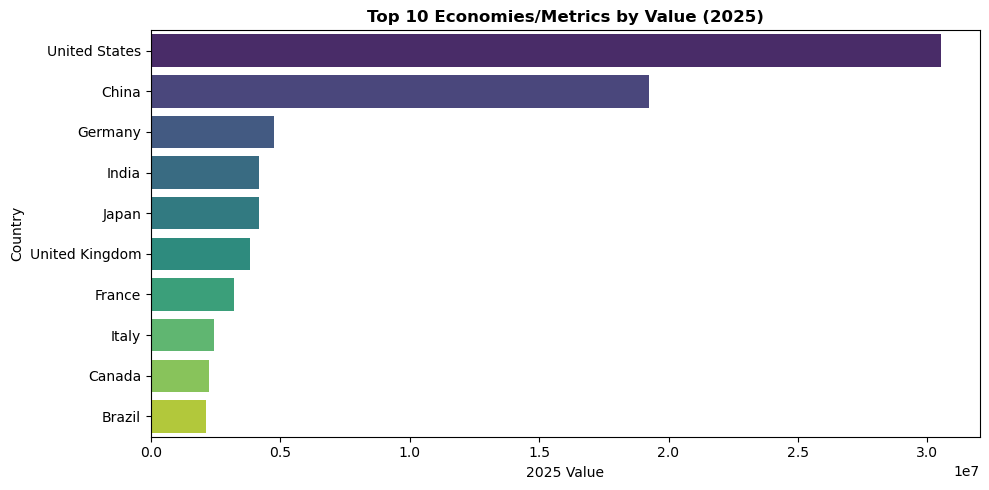

In [13]:
#Plot 1: Top 10 Countries in 2025
top10_2025 = df1.sort_values(by="2025", ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_2025, x="2025", y="Country", palette="viridis")
plt.title("Top 10 Economies/Metrics by Value (2025)", fontsize=12, fontweight="bold")
plt.xlabel("2025 Value")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("top10_economies_2025.png")
plt.show()

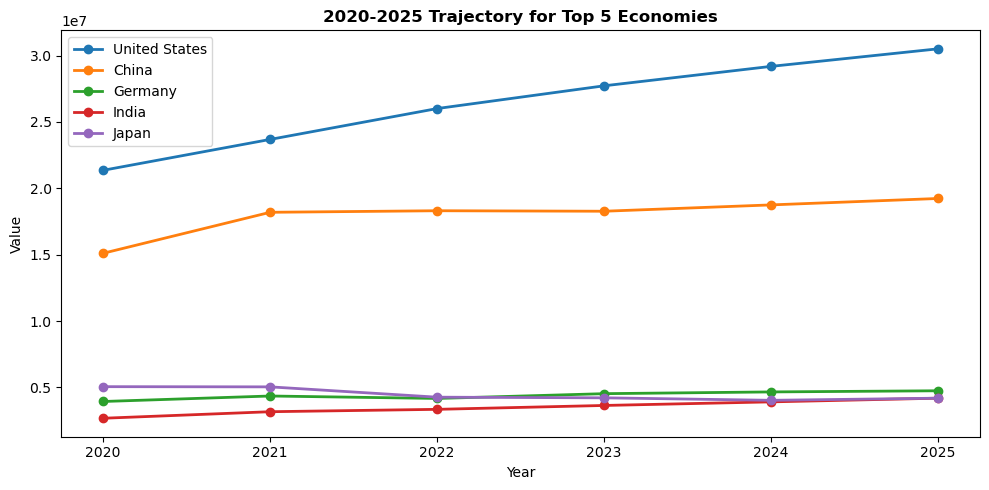

In [14]:
# Plot 2: 6-Year Trend Lines for Top 5 Economies
top5_countries = df1.sort_values(by="2025", ascending=False).head(5)
years = ["2020", "2021", "2022", "2023", "2024", "2025"]

plt.figure(figsize=(10, 5))
for _, row in top5_countries.iterrows():
    plt.plot(years, row[years], marker="o", linewidth=2, label=row["Country"])

plt.title("2020-2025 Trajectory for Top 5 Economies", fontsize=12, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.savefig("top5_trajectories.png")
plt.show()

# PART 2: Customer Churn Records

In [16]:
print("\nDemographics & Balance Summary Statistics:")
print(df2.describe())


Demographics & Balance Summary Statistics:
         CustomerId   CreditScore           Age        Tenure        Balance  \
count  1.000000e+04  10000.000000  10000.000000  10000.000000   10000.000000   
mean   1.569094e+07    650.528800     38.921800      5.012800   76485.889288   
std    7.193619e+04     96.653299     10.487806      2.892174   62397.405202   
min    1.556570e+07    350.000000     18.000000      0.000000       0.000000   
25%    1.562853e+07    584.000000     32.000000      3.000000       0.000000   
50%    1.569074e+07    652.000000     37.000000      5.000000   97198.540000   
75%    1.575323e+07    718.000000     44.000000      7.000000  127644.240000   
max    1.581569e+07    850.000000     92.000000     10.000000  250898.090000   

       NumOfProducts  
count   10000.000000  
mean        1.530200  
std         0.581654  
min         1.000000  
25%         1.000000  
50%         1.000000  
75%         2.000000  
max         4.000000  


In [17]:
#Aggregated Demographics
churn_summary = (
    df2.groupby(["Geography", "Gender"])
    .agg(
        Count=("CustomerId", "count"),
        Avg_CreditScore=("CreditScore", "mean"),
        Avg_Age=("Age", "mean"),
        Avg_Balance=("Balance", "mean"),
    )
    .reset_index()
)

print("\nDemographic Breakdown by Geography and Gender:")
print(churn_summary)


Demographic Breakdown by Geography and Gender:
  Geography  Gender  Count  Avg_CreditScore    Avg_Age    Avg_Balance
0    France  Female   2261       649.185759  38.773994   60322.670159
1    France    Male   2753       650.064657  38.296404   63546.284875
2   Germany  Female   1193       653.093881  40.154233  119145.966471
3   Germany    Male   1316       649.966565  39.424772  120259.668222
4     Spain  Female   1089       651.769513  39.199265   59862.092534
5     Spain    Male   1388       650.992075  38.649135   63352.833746


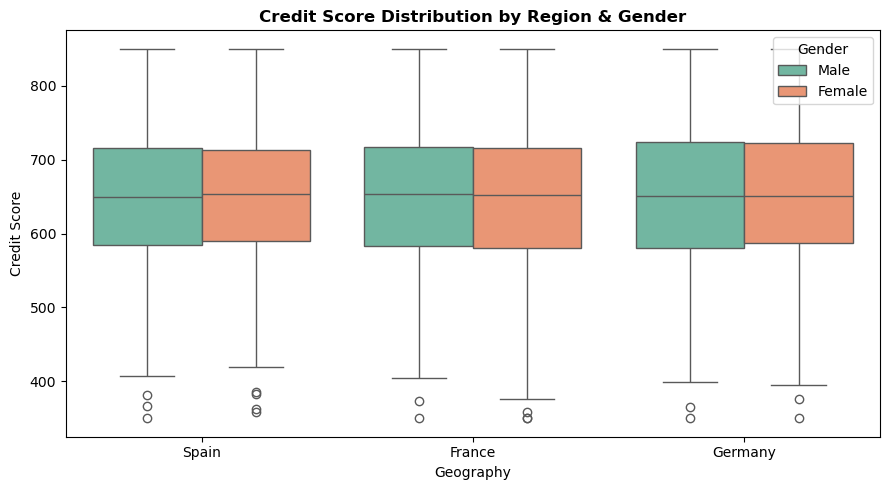

In [18]:
# Plot 3: Credit Score Boxplot by Geography and Gender
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df2,
    x="Geography",
    y="CreditScore",
    hue="Gender",
    palette="Set2",
)
plt.title("Credit Score Distribution by Region & Gender", fontsize=12, fontweight="bold")
plt.xlabel("Geography")
plt.ylabel("Credit Score")
plt.tight_layout()
plt.savefig("credit_score_distribution.png")
plt.show()

/var/folders/4d/j2zh3f0x41zgdh_wqkx7qvnm0000gn/T/ipykernel_45662/1780254305.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


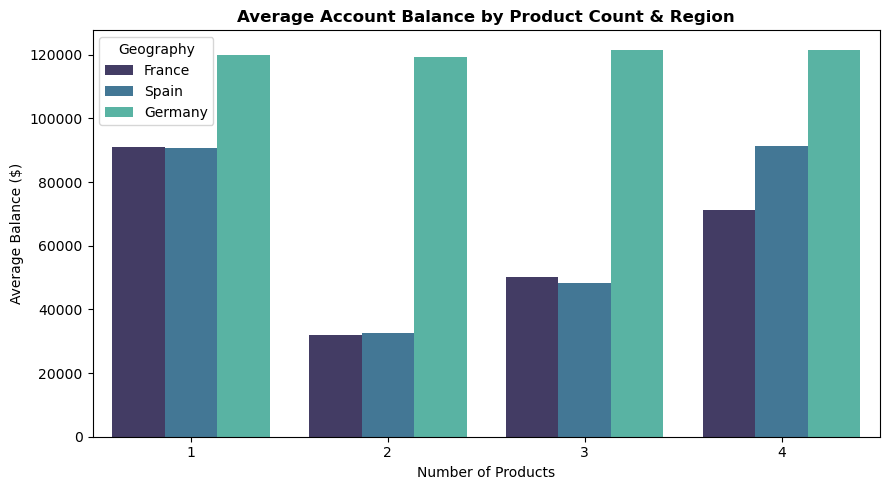

In [19]:
# Plot 4: Balance by Number of Products and Geograph
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df2,
    x="NumOfProducts",
    y="Balance",
    hue="Geography",
    ci=None,
    palette="mako",
)
plt.title("Average Account Balance by Product Count & Region", fontsize=12, fontweight="bold")
plt.xlabel("Number of Products")
plt.ylabel("Average Balance ($)")
plt.tight_layout()
plt.savefig("balance_by_products.png")
plt.show()

# Correlation

In [29]:
#Load both datasets
df_geo = pd.read_csv("2020-2025_CLEAN.csv")
df_churn = pd.read_csv("Customer-Churn-Records_CLEAN.csv")

#Join datasets on country level ('Geography' in churn data matches 'Country' in macro data)
df_merged = pd.merge(
    df_churn, df_geo, left_on="Geography", right_on="Country", how="inner"
)

In [30]:
#Select numerical features across both datasets
cols_for_correlation = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "2020",
    "2025",
]

In [33]:
#Calculate Pearson correlation matrix
corr_matrix = df_merged[cols_for_correlation].corr()

print("===Cross-dataset Correlation Matrix==")
print(corr_matrix)

===Cross-dataset Correlation Matrix==
               CreditScore       Age    Tenure   Balance  NumOfProducts  \
CreditScore       1.000000 -0.003965  0.000842  0.006268       0.012238   
Age              -0.003965  1.000000 -0.009997  0.028308      -0.030680   
Tenure            0.000842 -0.009997  1.000000 -0.012254       0.013444   
Balance           0.006268  0.028308 -0.012254  1.000000      -0.304180   
NumOfProducts     0.012238 -0.030680  0.013444 -0.304180       1.000000   
2020              0.000321  0.029131 -0.002763  0.324637      -0.011900   
2025              0.000739  0.030954 -0.002629  0.335318      -0.011952   

                   2020      2025  
CreditScore    0.000321  0.000739  
Age            0.029131  0.030954  
Tenure        -0.002763 -0.002629  
Balance        0.324637  0.335318  
NumOfProducts -0.011900 -0.011952  
2020           1.000000  0.998902  
2025           0.998902  1.000000  


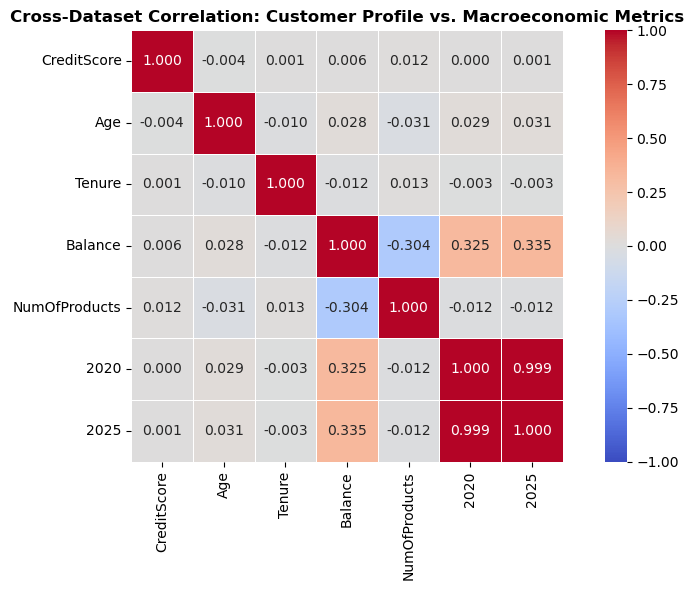

In [35]:
#Calculate Pearson correlation matrix
corr_matrix=df_merged[cols_for_correlation].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
)

plt.title(
    "Cross-Dataset Correlation: Customer Profile vs. Macroeconomic Metrics",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig("cross_dataset_correlation.png")
plt.show()

# ==============================================================================
# STRATEGIC RECOMMENDATIONS BASED ON DATA FINDINGS
# ==============================================================================

# Recommendation 1: Regional Banking & Capital Allocation
recommendation_1 = {
    "Strategy": "Prioritize High-Wealth Capital Markets",
    "Target_Region": "Germany",
    "Finding": "Germany demonstrates higher economic capacity (GDP ~$4.74M) and nearly double the average account balance ($119,730 vs ~$62,000 in France/Spain).",
    "Action_Item": "Allocate premium wealth management products and higher-yield deposit options to high-balance regions, while focusing on volume-based retail products in France and Spain.",
}

# Recommendation 2: Risk Assessment & Credit Scoring
recommendation_2 = {
    "Strategy": "Standardize Credit Risk Models Across Borders",
    "Finding": "Credit scores remain static (~650) regardless of regional GDP or balance levels (r = 0.0007).",
    "Action_Item": "Decouple regional macroeconomic GDP from individual credit scoring algorithms. Creditworthiness should continue to be evaluated on individual payment history rather than regional economic tier.",
}

# Recommendation 3: Product Portfolio Optimization
recommendation_3 = {
    "Strategy": "Address High-Balance Churn Risk in Multi-Product Segment",
    "Finding": "Holding multiple products negatively correlates with account balance (r = -0.304).",
    "Action_Item": "Re-evaluate multi-product bundling strategies to ensure high-net-worth individuals are not incentivized into low-value secondary products that dilute total deposited capital.",
}

# Output Recommendations
recommendations = [recommendation_1, recommendation_2, recommendation_3]

for i, rec in enumerate(recommendations, 1):
    print(f"RECOMMENDATION {i}: {rec['Strategy']}")
    print(f"  - Key Finding: {rec['Finding']}")
    print(f"  - Action Item: {rec['Action_Item']}\n")